# Предварительные действия

In [2]:
from shap import Explanation
import shap
from matplotlib import pyplot as plt
import numpy as np

In [3]:
from utils import DataProcessor
import pickle
with open('shap_explanation.pkl', 'rb') as f:
        explanation = pickle.load(f)

data = DataProcessor("../../hyper_wheat_ds_ch_norm_prep_mode=dai.csv").split_data()

# Интерпретация предсказания для одного объекта в тестовой выборке

Выводит только те признаки, которые имеют все более 5%, этот параметр можно поменять(contribution_threshold)

In [4]:
print("Базовое предсказание модели", round((explanation.base_values).mean(), 3))
explanation_round = Explanation(
    values=explanation.values,
    base_values=explanation.base_values,
    feature_names=explanation.feature_names,
    data=np.round(explanation.data, 3))

Базовое предсказание модели 0.058


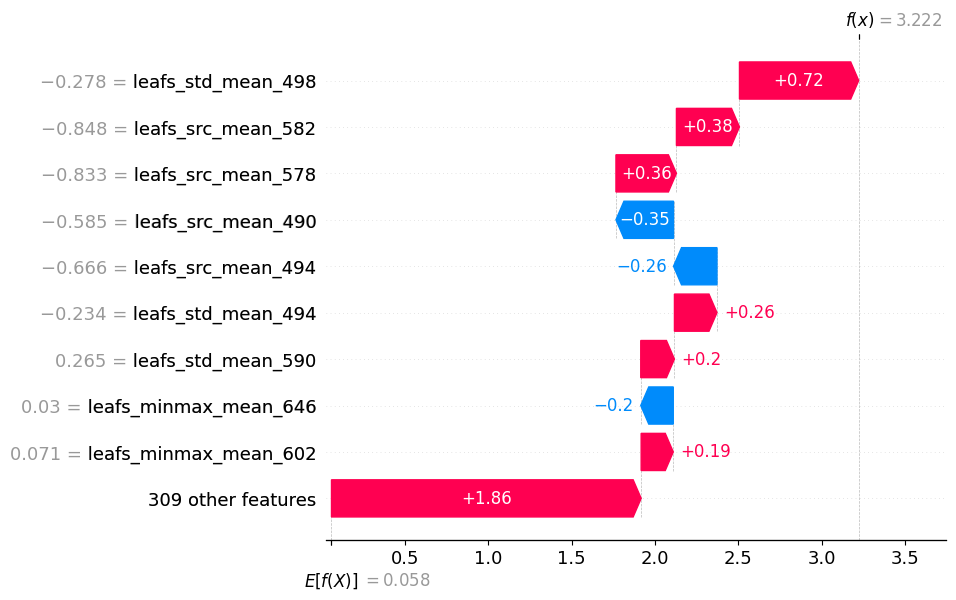

In [5]:
shap.plots.waterfall(explanation_round[0], show=False)  # Локальная статистика для 1 объекта
plt.show()

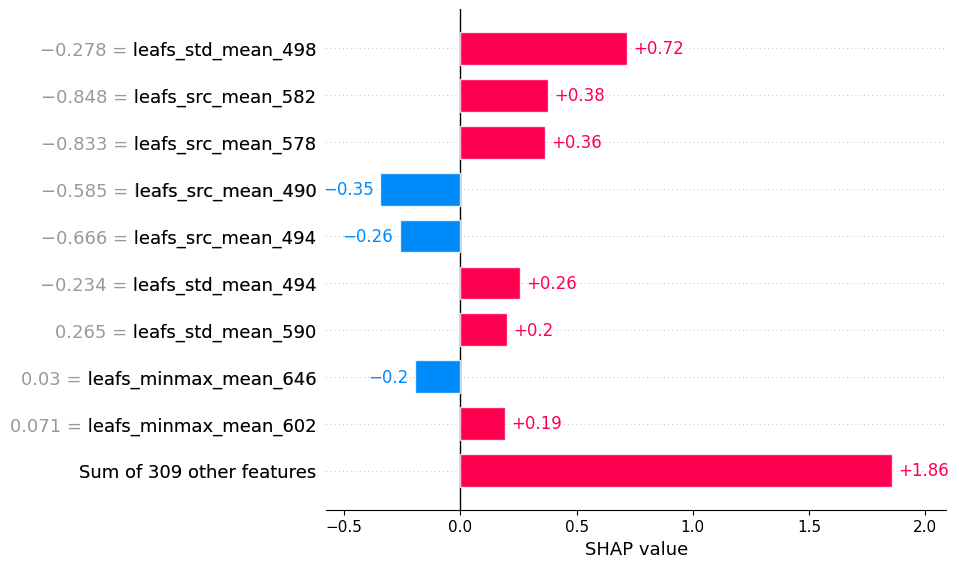

In [6]:
shap.plots.bar(explanation_round[0], show=False)
plt.show()

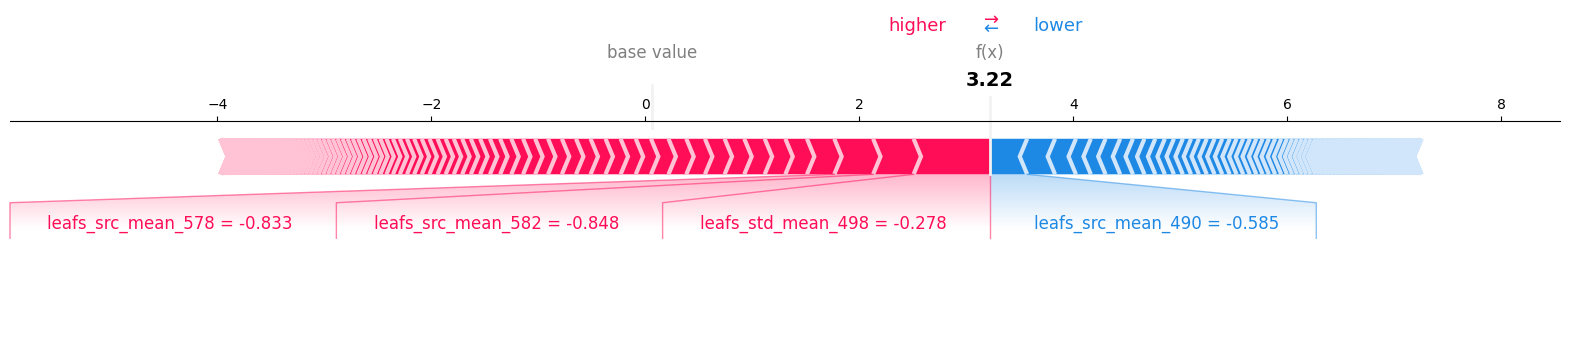

In [9]:
shap.plots.force(explanation_round[0], matplotlib=True, show=False, contribution_threshold=0.03)
plt.show()

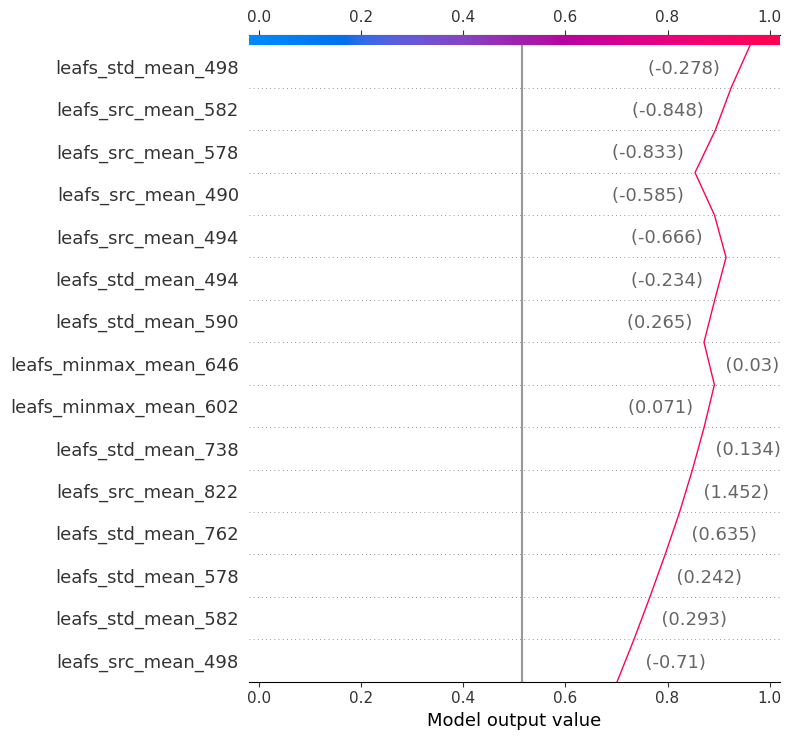

In [10]:
shap.decision_plot(
    explanation_round.base_values[0],
    explanation_round[0].values,
    explanation_round[0].data,
    feature_names=explanation_round.feature_names,
    feature_display_range=slice(-1, -16, -1),
    link='logit',
    ignore_warnings=True,
    show=False
)

plt.tight_layout()
plt.show()

# Интерпретазия предсказаний глобально


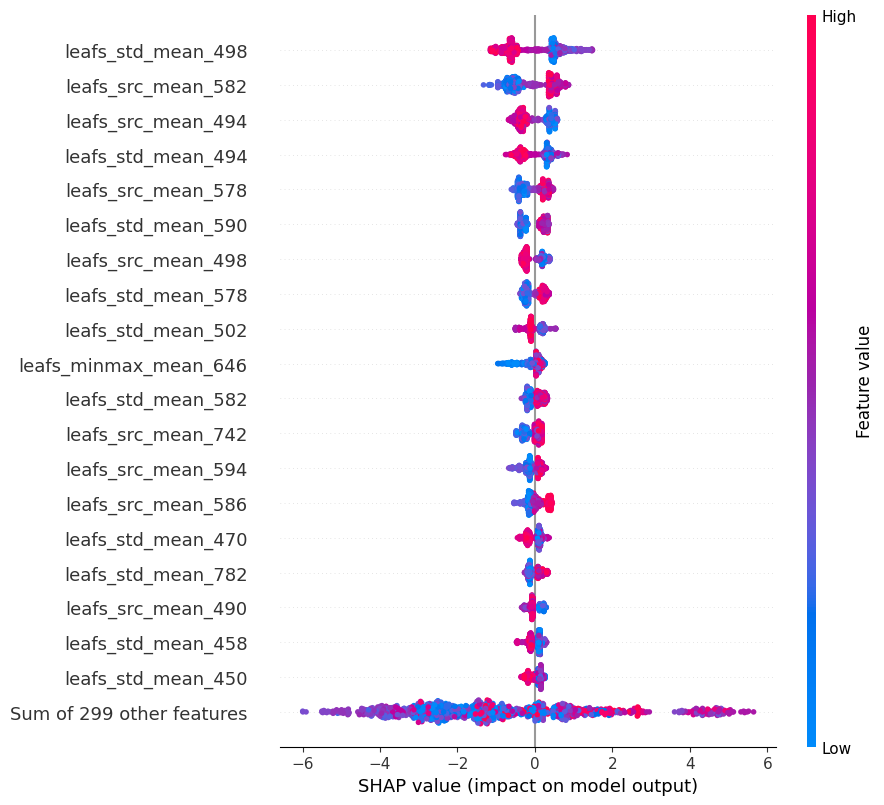

In [11]:
shap.plots.beeswarm(explanation_round, max_display=20, show=False)
plt.show()

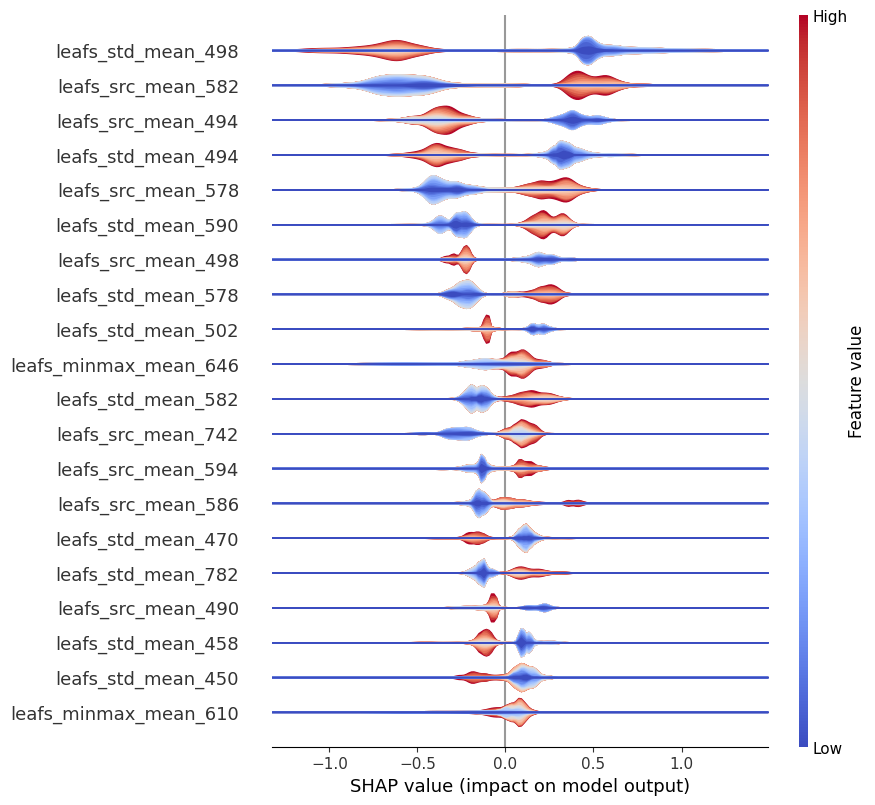

In [12]:
shap.plots.violin(explanation_round.values, features = data.x_test, feature_names=explanation_round.feature_names, plot_type="layered_violin")

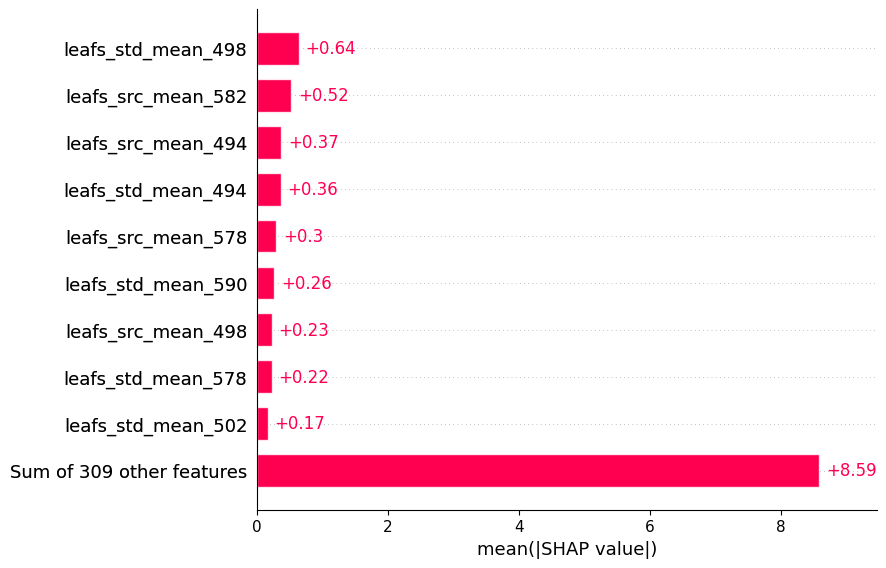

In [13]:
shap.plots.bar(explanation_round, show=False)
plt.show()

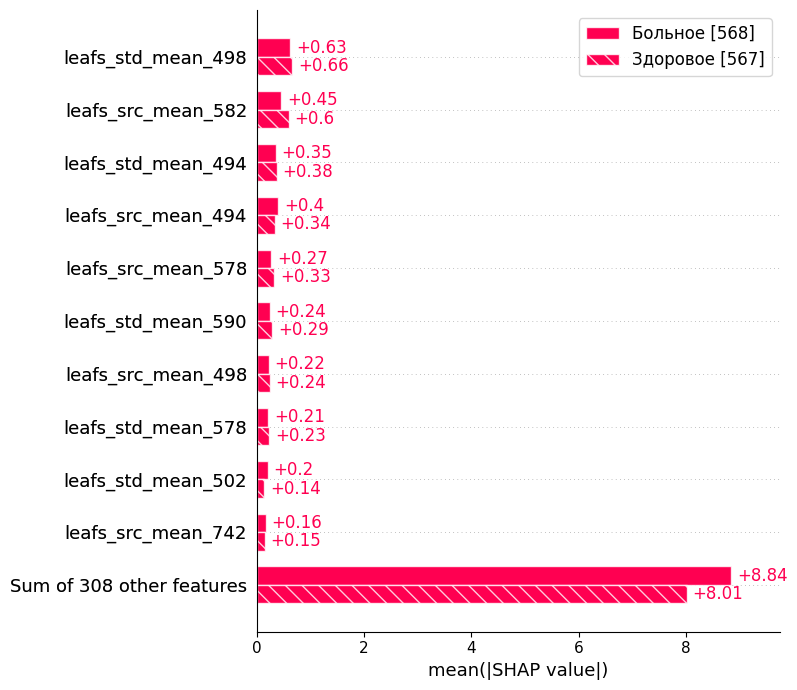

In [14]:
plant_class = ["Здоровое" if y == 0 else "Больное" for y in data.y_test]
ax = shap.plots.bar(explanation_round.cohorts(plant_class).abs.mean(0),max_display=11, show=False)
fig = ax.figure
fig.set_size_inches(8, 7)
plt.tight_layout()
plt.show()

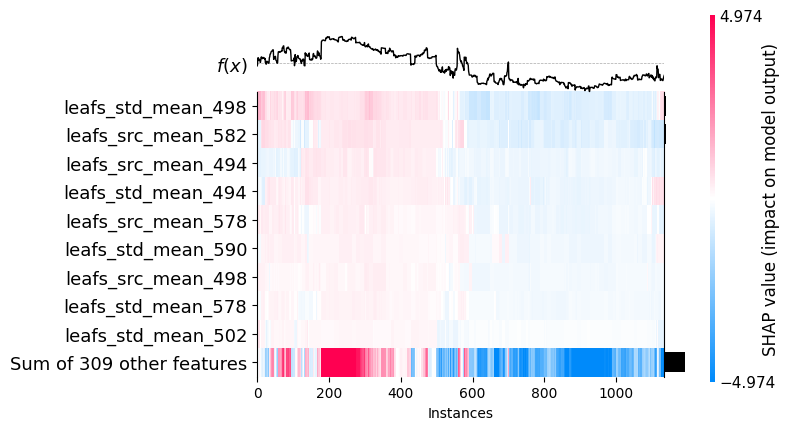

In [15]:
shap.plots.heatmap(
    explanation_round,
    max_display=10,
    show=False)
plt.tight_layout()
plt.show()


# Графики для 1 признака и его зависимости

Она не показывает зависимость между признаками

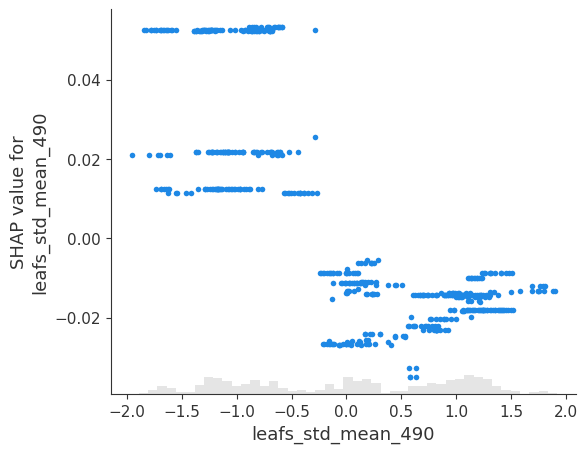

In [45]:
feature = "leafs_std_mean_490"
shap.plots.scatter(explanation[:, feature])

Если необходимо увидеть корреляцию признаков. Сбоку выводится тот признак, который коррелириует сильнее всего(справа)

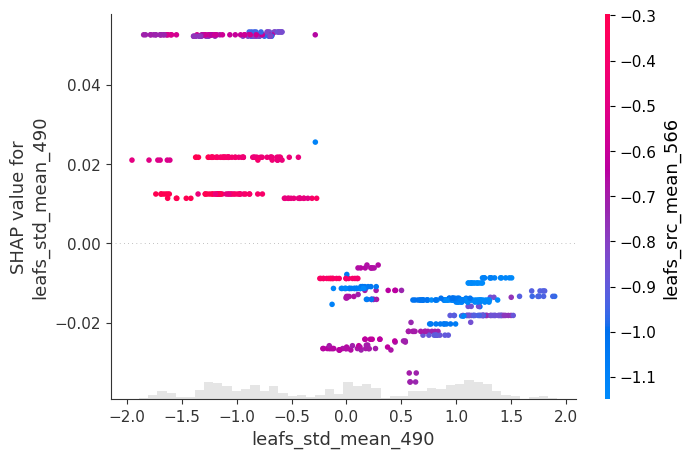

In [46]:
shap.plots.scatter(explanation[:, feature], color=explanation)

### Построение графика самого влиятельного признака

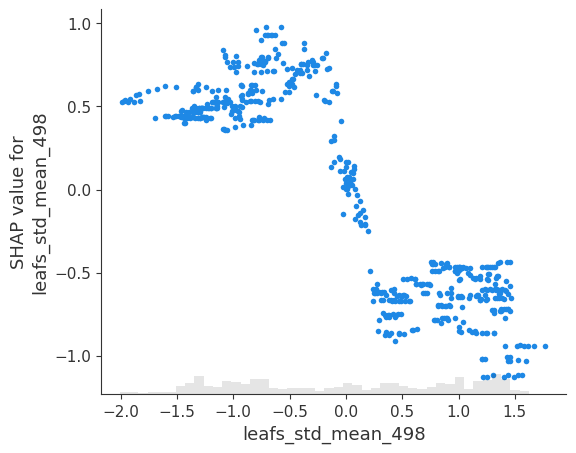

In [47]:
shap.plots.scatter(explanation[:, explanation.abs.mean(0).argsort[-1]])

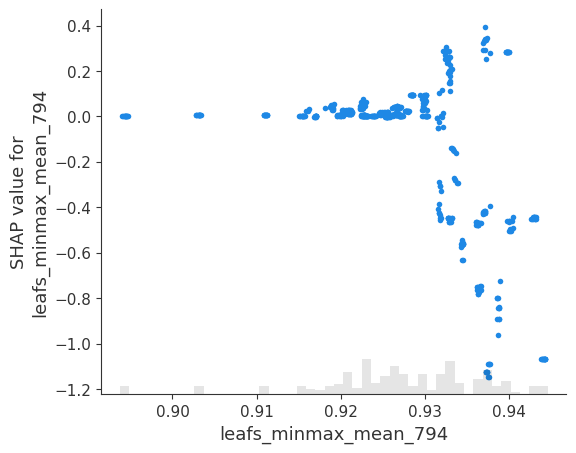

In [48]:
shap.plots.scatter(explanation[:, explanation.abs.max(0).argsort[-1]])

# Сравнение интерпретации нескольких объектов одной моделью

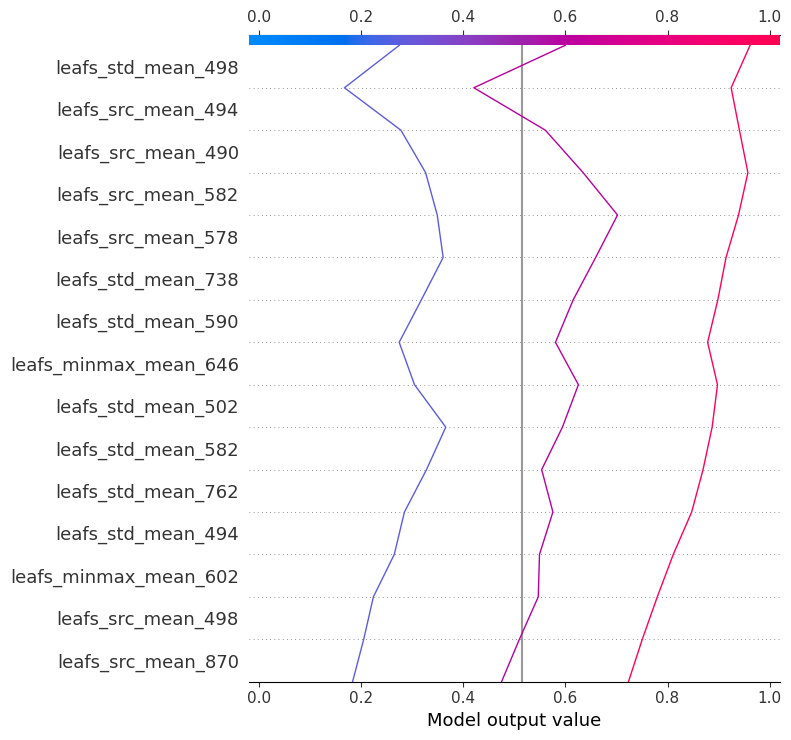

In [16]:
shap.decision_plot(
    explanation.base_values[0],
    explanation[0:3].values,
    explanation[0:3].data,
    feature_names=explanation.feature_names,
    feature_display_range=slice(-1, -16, -1),
    # feature_display_range=slice(None, None, None),
    link='logit',
    ignore_warnings=True, #если использовать все признаки
    show=False)
plt.tight_layout()
plt.show()